# APOPO Sniff Times: basic data exploration (bronze)

Source: `../data/bronze/data_bronze.xlsb` (AutomatedCage Sept 2023 - Sept 2024). The source is never modified; all transformations happen on an in-memory copy.

**Reminders from the Data Guide**
- One row = one recorded rat-sample evaluation, not one patient. Repeated sample IDs are expected.
- `HIT` is a screening signal, not a diagnosis. `SniffTime` is in milliseconds.
- `tblEVALUATION_SniffThreshold` drives HIT; `tblRAT_SESSION_SniffThreshold` is context only.
- Blank `ID_BL_APOPO` is *not tested*, not negative.
- Never define diagnostic truth with HIT, SniffTime or REWARD.

Requirements: `pip install pandas pyxlsb matplotlib`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

DATA_PATH = Path("../data/bronze/data_bronze.xlsb")

## 1. Load and convert dates

In [2]:
raw = pd.read_excel(DATA_PATH, engine="pyxlsb")
df = raw.copy()

# Excel day serials -> datetime (origin 1899-12-30)
for col in ["SESSION_DATE", "DATE_INCOMING", "START_TIME", "END_TIME"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], unit="D", origin="1899-12-30", errors="coerce")

print(df.shape)
df.head()

(204740, 34)


,RAT_NAME,ID_PATIENT,ID_SAMPLE,LEVEL_NAME,RUN,HOLE,ID_BL_DOTS,ID_GXP_DOTS,ID_BL_APOPO,ID_GXP_APOPO,HIT,REWARD,SniffTime,ReadTotalSnifftime,SESSION_DATE,ID_EVALUATION_SESSION,STATUS_BLINDPOS,SAMPLE_TYPE,tblRAT_SESSION_REMARKS,REUSED,tblEVALUATION_SniffThreshold,tblRAT_SESSION_SniffThreshold,CONFIGURATION_NAME,TEMPERATURE,STATUS_KNOWNPOS,START_TIME,END_TIME,DATE_INCOMING,tblEVALUATION_SESSION_REMARKS,Trainer,Documenter,Handler,DOTS_NAME,ID_CONFIGURATION
0,Ella,236970,569474,3AFB,A,1,4,NaN,NaN,NaN,False,False,784,True,2023-09-01,22012,False,NaN,NaN,81,1000,NaN,Line E-3H,0.0,True,2023-09-01 10:44:06.066997336,2023-09-01 10:50:35.476998538,2018-06-07,Indication - Chamomile,NaN,NaN,NaN,Sabasaba 2,5
1,Ella,205372,525681,1+,A,2,11,NaN,NaN,NaN,False,False,724,True,2023-09-01,22012,False,NaN,NaN,57,1000,NaN,Line E-3H,0.0,True,2023-09-01 10:44:06.066997336,2023-09-01 10:50:35.476998538,2017-04-09,Indication - Chamomile,NaN,NaN,NaN,Lugalo,5
2,Ella,222635,548001,1+,A,3,11,NaN,NaN,NaN,True,True,2599,True,2023-09-01,22012,False,NaN,NaN,58,0,NaN,Line E-3H,0.0,True,2023-09-01 10:44:06.066997336,2023-09-01 10:50:35.476998538,2017-12-06,Indication - Chamomile,NaN,NaN,NaN,Amana,5
3,Ella,207500,525331,3+,B,1,13,NaN,NaN,NaN,True,True,2576,True,2023-09-01,22012,False,NaN,NaN,57,1000,NaN,Line E-3H,0.0,True,2023-09-01 10:44:06.066997336,2023-09-01 10:50:35.476998538,2017-04-09,Indication - Chamomile,NaN,NaN,NaN,Tandale,5
4,Ella,207680,525587,3+,B,2,13,NaN,NaN,NaN,False,False,755,True,2023-09-01,22012,False,NaN,NaN,58,1000,NaN,Line E-3H,0.0,True,2023-09-01 10:44:06.066997336,2023-09-01 10:50:35.476998538,2017-04-09,Indication - Chamomile,NaN,NaN,NaN,Mnazi mmoja,5


## 2. Structure and key counts
Compare with the guide: 204,740 rows, 34 columns, 15 rats, 12,809 samples, 11,346 patients, 645 sessions.

In [3]:
summary = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "distinct rats": df["RAT_NAME"].nunique(),
    "distinct samples": df["ID_SAMPLE"].nunique(),
    "distinct patients": df["ID_PATIENT"].nunique(),
    "distinct sessions": df["ID_EVALUATION_SESSION"].nunique(),
    "first session date": df["SESSION_DATE"].min(),
    "last session date": df["SESSION_DATE"].max(),
})
summary

rows                               204740
columns                                34
distinct rats                          15
distinct samples                    12809
distinct patients                   11346
distinct sessions                     645
first session date    2023-09-01 00:00:00
last session date     2024-09-30 00:00:00
dtype: object

In [4]:
pd.DataFrame({"dtype": df.dtypes, "n_unique": df.nunique(), "n_missing": df.isna().sum(),
              "pct_missing": (df.isna().mean() * 100).round(1)})

,dtype,n_unique,n_missing,pct_missing
RAT_NAME,str,15,0,0.0
ID_PATIENT,int64,11346,0,0.0
ID_SAMPLE,int64,12809,0,0.0
LEVEL_NAME,str,20,0,0.0
RUN,str,10,0,0.0
HOLE,int64,10,0,0.0
ID_BL_DOTS,int64,16,0,0.0
ID_GXP_DOTS,float64,4,111715,54.6
ID_BL_APOPO,float64,12,190019,92.8
ID_GXP_APOPO,float64,0,204740,100.0


## 3. Missing values

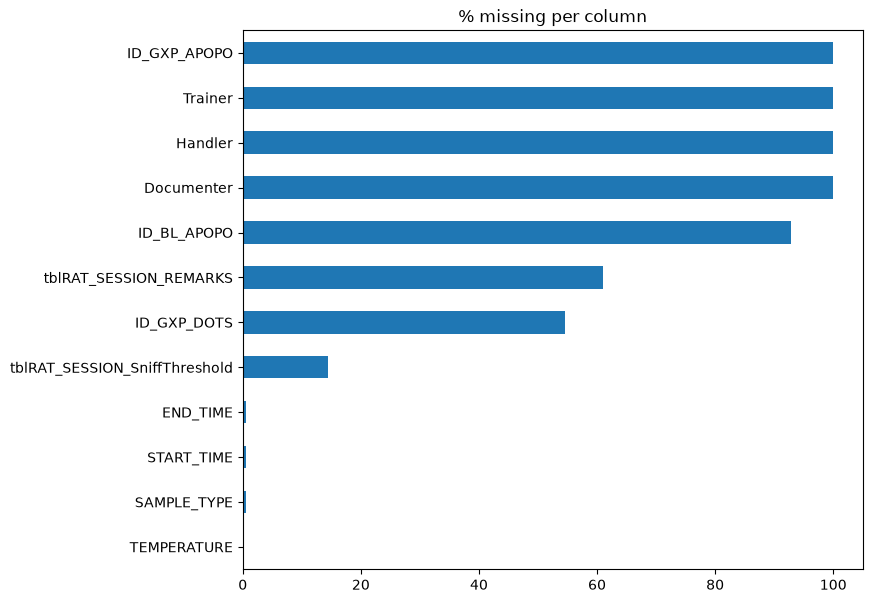

In [5]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
ax = missing[missing > 0].plot.barh(figsize=(8, 7), title="% missing per column")
ax.invert_yaxis()
plt.show()

## 4. Rows per rat, sample type, clinic, configuration

In [6]:
for col in ["RAT_NAME", "SAMPLE_TYPE", "DOTS_NAME", "CONFIGURATION_NAME", "LEVEL_NAME"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20), "\n")

--- RAT_NAME ---
RAT_NAME
Gea         18362
Salvina     17692
Kenenisa    17397
Tamasha     17197
Bieber      16223
Tirunesh    16110
Splinter    16049
Chamy       15786
Tivane      14701
Mayele      13729
Chilleta    10949
Malaika      9518
Ella         8307
Orpheus      6390
Bertha       6330
Name: count, dtype: int64 

--- SAMPLE_TYPE ---
SAMPLE_TYPE
BigNewPot    142904
Old pot       29434
SUG            8537
SAL            8505
BTE            8490
CAM            5337
NaN            1166
Pre             231
New Pot         136
Name: count, dtype: int64 

--- DOTS_NAME ---
DOTS_NAME
SurrogateExp       30869
Mbagala Rangi 3    17697
Mwananyamala       11834
Sabasaba 2          9666
Keko                5374
Mnazi mmoja         5325
Kizuiani            5225
Sinza               5198
Chalinze            4740
Upendano            4285
Turiani             4252
Dodoma              4121
Chanika             4046
Morogoro            3908
Amana               3800
Magomeni            3551
Segerea 

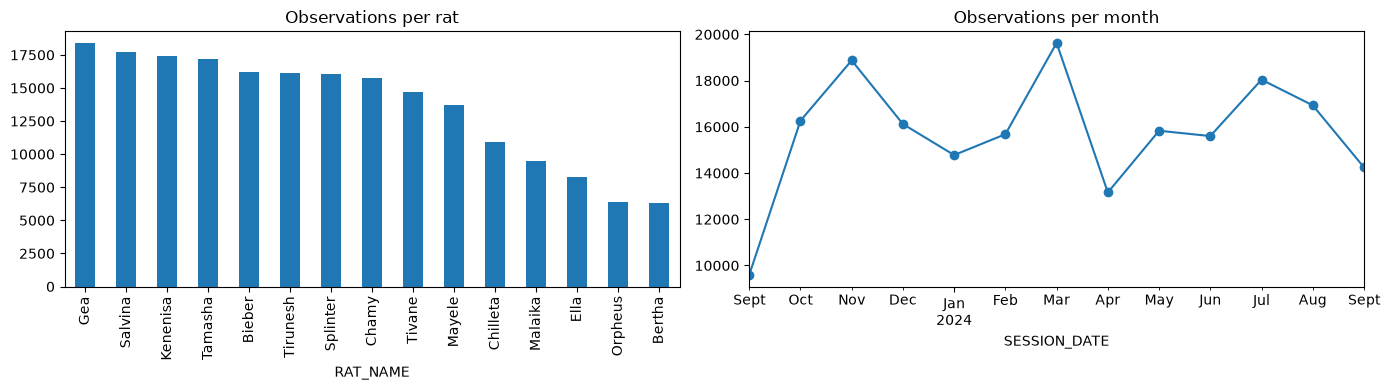

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["RAT_NAME"].value_counts().plot.bar(ax=axes[0], title="Observations per rat")
df.groupby(df["SESSION_DATE"].dt.to_period("M")).size().plot(ax=axes[1], marker="o", title="Observations per month")
plt.tight_layout()
plt.show()

## 5. Repeated samples and reuse
Repeated sample IDs are expected; this just quantifies them.

In [8]:
rows_per_sample = df.groupby("ID_SAMPLE").size()
print(rows_per_sample.describe())
print("\nREUSED distribution:")
print(df["REUSED"].value_counts(dropna=False).sort_index().head(20))

count    12809.000000
mean        15.984074
std         19.872864
min          1.000000
25%         10.000000
50%         13.000000
75%         16.000000
max        209.000000
dtype: float64

REUSED distribution:
REUSED
1     36927
2      5529
3     81263
4      4465
5     16724
6      3507
7      4790
8      2385
9       644
10      779
11      806
12      793
13      670
14     1321
15     2320
16     1854
17      354
18      501
19      446
20      331
Name: count, dtype: int64


## 6. SniffTime

In [9]:
st = df["SniffTime"]
print(st.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print("\nzero sniff times:", (st == 0).sum(), "| missing:", st.isna().sum())
print("zero sniff time with HIT:", ((st == 0) & (df["HIT"] == True)).sum(),
      "| with REWARD:", ((st == 0) & (df["REWARD"] == True)).sum())

count    204740.000000
mean        719.074382
std        1016.102163
min           0.000000
1%            0.000000
5%            0.000000
25%         154.000000
50%         339.000000
75%         753.000000
95%        3108.000000
99%        4086.000000
max       21926.000000
Name: SniffTime, dtype: float64

zero sniff times: 28424 | missing: 0
zero sniff time with HIT: 2176 | with REWARD: 1137


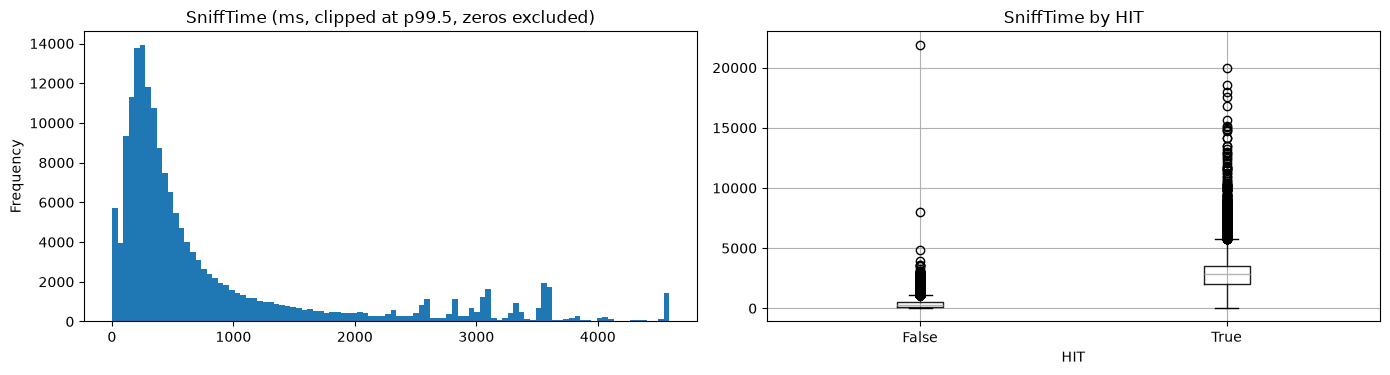

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
st[st > 0].clip(upper=st.quantile(0.995)).plot.hist(
    bins=100, ax=axes[0], title="SniffTime (ms, clipped at p99.5, zeros excluded)")
df.boxplot(column="SniffTime", by="HIT", ax=axes[1])
axes[1].set_title("SniffTime by HIT")
plt.suptitle("")
plt.tight_layout()
plt.show()

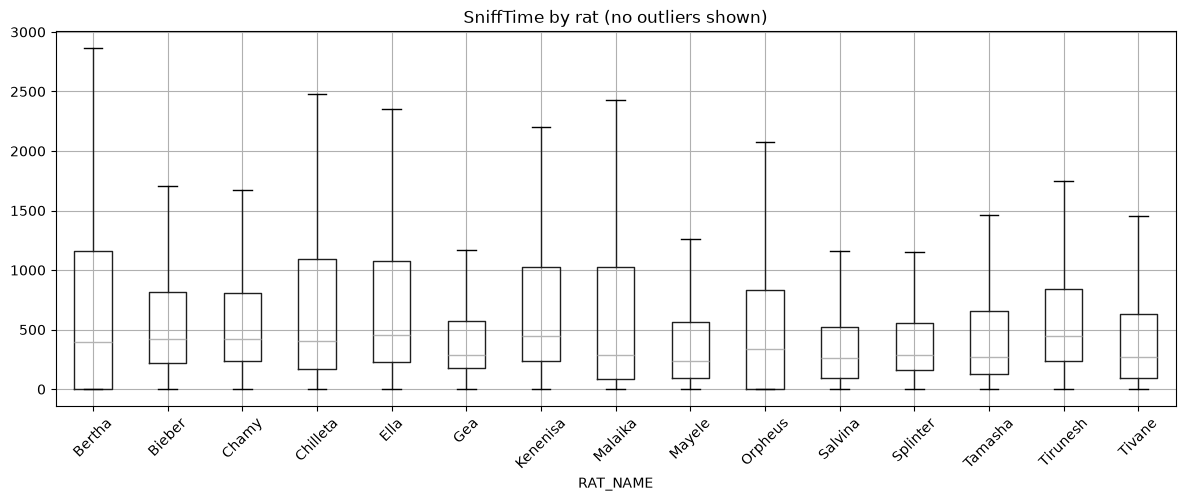

In [11]:
# Sniff time per rat
df.boxplot(column="SniffTime", by="RAT_NAME", figsize=(14, 5), rot=45, showfliers=False)
plt.title("SniffTime by rat (no outliers shown)")
plt.suptitle("")
plt.show()

## 7. Thresholds and HIT
Checks the guide's claim that HIT follows `tblEVALUATION_SniffThreshold`.

In [12]:
print(df["tblEVALUATION_SniffThreshold"].value_counts(dropna=False).head(15))
print()
print(df["tblRAT_SESSION_SniffThreshold"].value_counts(dropna=False).head(10))

tblEVALUATION_SniffThreshold
0       161898
2000     14071
1500      8144
1000      3634
1750      3390
1250      2904
3000      2585
1375      2208
1800      1362
2250      1210
2500      1010
750        606
850        532
1600       182
2350       178
Name: count, dtype: int64

tblRAT_SESSION_SniffThreshold
2000.0    175035
NaN        29605
1800.0       100
Name: count, dtype: int64


In [13]:
thr = df["tblEVALUATION_SniffThreshold"]
valid = thr > 0
df["hit_from_eval_thr"] = df["SniffTime"] >= thr

print("Rows with eval threshold = 0 / missing:", (~valid).sum())
agree = df.loc[valid, "hit_from_eval_thr"] == df.loc[valid, "HIT"].astype(bool)
print(f"HIT matches (SniffTime >= eval threshold): {agree.mean():.2%} of {valid.sum():,} rows")

print("\nMismatches per rat:")
print(df.loc[valid].loc[~agree, "RAT_NAME"].value_counts())

Rows with eval threshold = 0 / missing: 161898
HIT matches (SniffTime >= eval threshold): 97.22% of 42,842 rows

Mismatches per rat:
RAT_NAME
Malaika     126
Chilleta    107
Ella        102
Kenenisa     96
Tamasha      90
Mayele       89
Salvina      87
Tirunesh     83
Bieber       75
Gea          74
Tivane       68
Chamy        57
Splinter     50
Orpheus      43
Bertha       42
Name: count, dtype: int64


In [14]:
# Threshold per rat (evaluation threshold)
df[valid].groupby("RAT_NAME")["tblEVALUATION_SniffThreshold"].agg(["min", "median", "max", "nunique"])

,min,median,max,nunique
RAT_NAME,,,,
Bertha,500,1500.0,2000,10
Bieber,1000,1500.0,2500,10
Chamy,1000,2000.0,2350,8
Chilleta,500,1500.0,2500,14
Ella,500,1000.0,2000,13
Gea,500,2000.0,3000,10
Kenenisa,1250,2250.0,3000,8
Malaika,500,1250.0,2000,8
Mayele,500,1250.0,2250,8


## 8. Diagnostic reference columns
Codes: 0 = unknown, 1 = negative, 2-10 = 1-9 AFB, 11-13 = 1+/2+/3+, 15-24 = 10-19 AFB. Blank = not tested.

In [15]:
for col in ["ID_BL_DOTS", "ID_GXP_DOTS", "ID_BL_APOPO"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())
    print()

--- ID_BL_DOTS ---
ID_BL_DOTS
1     177973
2        200
3        467
4        642
5        377
6        526
7        392
8        328
9        191
10       106
11      5696
12     11482
13      6141
15        52
20        30
24       137
Name: count, dtype: int64

--- ID_GXP_DOTS ---
ID_GXP_DOTS
1.0     92783
2.0       205
4.0        31
8.0         6
NaN    111715
Name: count, dtype: int64

--- ID_BL_APOPO ---
ID_BL_APOPO
1.0      13362
3.0         28
4.0         40
5.0        197
6.0        230
7.0         75
8.0         57
9.0         98
10.0        13
11.0       240
12.0       130
13.0       251
NaN     190019
Name: count, dtype: int64



In [16]:
# Which rows can be classified against which reference?
new_case = (df["ID_BL_DOTS"] == 1) & df["ID_BL_APOPO"].notna() & (df["ID_BL_APOPO"] != 1)
refs = pd.DataFrame({
    "clinic microscopy positive (>1)": df["ID_BL_DOTS"] > 1,
    "clinic microscopy negative (==1)": df["ID_BL_DOTS"] == 1,
    "clinic microscopy unknown/blank": df["ID_BL_DOTS"].isna() | (df["ID_BL_DOTS"] == 0),
    "APOPO confirmation tested": df["ID_BL_APOPO"].notna(),
    "APOPO confirmed positive": df["ID_BL_APOPO"].notna() & (df["ID_BL_APOPO"] != 1),
    "new case (clinic neg, APOPO pos)": new_case,
    "STATUS_KNOWNPOS": df["STATUS_KNOWNPOS"] == True,
    "STATUS_BLINDPOS": df["STATUS_BLINDPOS"] == True,
}).sum().rename("rows")
refs

clinic microscopy positive (>1)      26767
clinic microscopy negative (==1)    177973
clinic microscopy unknown/blank          0
APOPO confirmation tested            14721
APOPO confirmed positive              1359
new case (clinic neg, APOPO pos)      1017
STATUS_KNOWNPOS                       4696
STATUS_BLINDPOS                       2509
Name: rows, dtype: int64

## 9. First performance view vs. clinic microscopy
**Only one of several reference definitions** (see the Data Guide). Always state counts next to the percentages.

In [17]:
ref = df[df["ID_BL_DOTS"].notna() & (df["ID_BL_DOTS"] != 0)].copy()
ref["positive"] = ref["ID_BL_DOTS"] > 1
ref["HIT"] = ref["HIT"].astype(bool)


def perf(g):
    tp = (g.HIT & g.positive).sum()
    fn = (~g.HIT & g.positive).sum()
    fp = (g.HIT & ~g.positive).sum()
    tn = (~g.HIT & ~g.positive).sum()
    return pd.Series({
        "TP": tp, "FN": fn, "FP": fp, "TN": tn,
        "sensitivity": tp / (tp + fn) if tp + fn else np.nan,
        "specificity": tn / (tn + fp) if tn + fp else np.nan,
        "accuracy": (tp + tn) / len(g) if len(g) else np.nan,
    })


print("Overall:")
print(perf(ref).round(4).to_frame().T)
print("\nPer rat:")
ref.groupby("RAT_NAME").apply(perf, include_groups=False).round(3)

Overall:
        TP      FN       FP        TN  sensitivity  specificity  accuracy
0  18651.0  8116.0  10938.0  167035.0       0.6968       0.9385    0.9069

Per rat:


,TP,FN,FP,TN,sensitivity,specificity,accuracy
RAT_NAME,,,,,,,
Bertha,801.0,309.0,472.0,4748.0,0.722,0.910,0.877
Bieber,1302.0,522.0,919.0,13480.0,0.714,0.936,0.911
Chamy,1331.0,494.0,659.0,13302.0,0.729,0.953,0.927
Chilleta,1460.0,686.0,953.0,7850.0,0.680,0.892,0.850
Ella,1247.0,700.0,930.0,5430.0,0.640,0.854,0.804
Gea,1498.0,411.0,545.0,15908.0,0.785,0.967,0.948
Kenenisa,1458.0,451.0,1075.0,14413.0,0.764,0.931,0.912
Malaika,1340.0,633.0,859.0,6686.0,0.679,0.886,0.843
Mayele,1155.0,622.0,647.0,11305.0,0.650,0.946,0.908


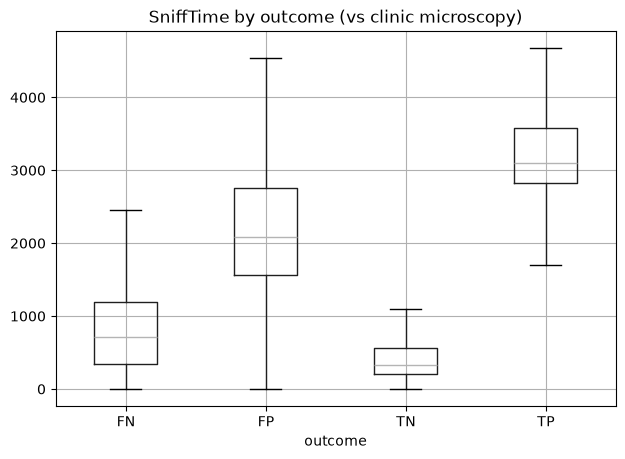

In [18]:
# Sniff-time distribution by outcome class
ref["outcome"] = np.select(
    [ref.HIT & ref.positive, ~ref.HIT & ref.positive, ref.HIT & ~ref.positive],
    ["TP", "FN", "FP"], default="TN")
ref[ref.SniffTime > 0].boxplot(column="SniffTime", by="outcome", figsize=(7, 5), showfliers=False)
plt.title("SniffTime by outcome (vs clinic microscopy)")
plt.suptitle("")
plt.show()

## 10. Session context: temperature and timing

In [19]:
print("Temperature:")
print(df["TEMPERATURE"].describe())
print("zero temperature rows:", (df["TEMPERATURE"] == 0).sum())

dur = (df["END_TIME"] - df["START_TIME"]).dt.total_seconds() / 60
print("\nEvaluation duration (min):")
print(dur.describe())

Temperature:
count    204390.000000
mean         16.394618
std           8.695908
min           0.000000
25%          21.000000
50%          21.000000
75%          21.000000
max          28.000000
Name: TEMPERATURE, dtype: float64
zero temperature rows: 44864

Evaluation duration (min):
count    203570.000000
mean         16.610739
std          91.387207
min           0.033600
25%           9.827667
50%          12.852550
75%          17.402000
max        4012.895217
dtype: float64


In [20]:
# Remarks and staff fields populated?
for col in ["tblRAT_SESSION_REMARKS", "tblEVALUATION_SESSION_REMARKS", "Trainer", "Documenter", "Handler"]:
    print(f"{col}: {df[col].notna().sum():,} populated rows")

tblRAT_SESSION_REMARKS: 79,684 populated rows
tblEVALUATION_SESSION_REMARKS: 204,740 populated rows
Trainer: 30 populated rows
Documenter: 30 populated rows
Handler: 30 populated rows


## 11. Next steps
- Decide the unit of analysis (observation / unique sample / unique patient).
- Agree the diagnostic reference with APOPO (microscopy, GeneXpert, APOPO confirmation) and handle conflicts explicitly.
- Review surrogate sample types (SUG, SAL, BTE, CAM) before choosing a clinical cohort.
- Investigate the ~3% of HITs that do not follow the evaluation threshold, and rows with threshold 0.
- Look at errors near the threshold (grey zone) per rat and per configuration.